# Proyecto Final: Predicción de Precios de Arriendo en la Región Metropolitana mediante Machine Learning

**Autor:** Vicente Tejos  
**Curso:** Data Scientist II - Coderhouse  
**Proyecto:** Radiografía del Mercado de Arriendos en la Región Metropolitana  
**Etapa:** Modelamiento predictivo y evaluación de modelos de Machine Learning  

**Fuente de Datos:** [Propiedades Alquiler PortalInmobiliario (Kaggle)](https://www.kaggle.com/datasets/edwight/propiedades-alquiler-portalinmobiliario)
---

## Resumen del proyecto

El presente proyecto tiene como objetivo construir y evaluar modelos de Machine Learning capaces de predecir el precio mensual de arriendo de propiedades ubicadas en la Región Metropolitana de Chile.

La propuesta da continuidad al análisis exploratorio realizado previamente sobre el mercado de arriendos, incorporando una etapa de modelamiento predictivo basada en técnicas de regresión supervisada. Para ello, se utilizaron variables asociadas a características físicas de las propiedades, ubicación geográfica, gastos comunes, cantidad de dormitorios, baños, estacionamientos, bodegas y comuna.

Durante el desarrollo del notebook se aplican procesos de limpieza de datos, tratamiento de valores anómalos, ingeniería de atributos, preprocesamiento de variables numéricas y categóricas, entrenamiento de modelos, validación cruzada, optimización de hiperparámetros y comparación de resultados.

---

## Objetivo general

Desarrollar un modelo predictivo que permita estimar el precio mensual de arriendo de propiedades en la Región Metropolitana, utilizando variables inmobiliarias y geográficas relevantes.

---

## Objetivos específicos

- Preparar y limpiar el dataset para su uso en modelos de Machine Learning.
- Corregir valores anómalos e inconsistencias en variables como superficies, precios y características de las propiedades.
- Crear nuevas variables mediante ingeniería de atributos.
- Entrenar y comparar distintos modelos de regresión.
- Optimizar hiperparámetros de los modelos con mejor desempeño.
- Evaluar un modelo ensemble basado en Voting Regressor.
- Seleccionar el modelo final según métricas de desempeño como MAE, RMSE y R².
- Interpretar los resultados desde una perspectiva técnica y de negocio.

---

## Problema de Machine Learning

El problema se aborda como una tarea de **regresión supervisada**, donde la variable objetivo corresponde al precio mensual de arriendo de una propiedad.

La variable objetivo es:

`precio`

Las variables predictoras incluyen atributos como superficie total, superficie útil, superficie de terraza, dormitorios, baños, estacionamientos, bodegas, gastos comunes, comuna, ubicación geográfica y variables derivadas creadas durante la ingeniería de atributos.

---

## Audiencia objetivo

Este proyecto puede ser útil para inversionistas inmobiliarios, arrendatarios, analistas de mercado y personas interesadas en estimar valores de arriendo de forma más objetiva, considerando características reales de las propiedades disponibles en la Región Metropolitana.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

# Cargar dataset

In [2]:
# Ajusta el nombre del archivo si corresponde
csv_path = "clean_alquiler_02_11_2023cc.csv"

df = pd.read_csv(csv_path)

df.head()

,Unnamed: 0,id,link,titulo,precio,direction,superficie_total,superficie_util,superficie_terraza,ambientes,...,numero_piso_unidad,codigo,fecha,published_time,latitude,longitude,comuna,published,divisa,region
0,0,1,https://www.portalinmobiliario.com/mlc-1321634...,edificio av. departamental- vista norte piso 16,400000.0,"av. departamental 900 - 1200, lo vial, san miguel",34.0,34.0,0.0,3,...,16,459500,2023-02-11 00:00:00.000000,publicado hace 2 días por assetplan chile,-33.504288,-70.650536,San miguel,2023-02-10 17:56:38.667783,pesos,Rm (metropolitana)
1,1,2,https://www.portalinmobiliario.com/mlc-1321564...,edificio garcía reyes- vista poniente piso 5,410000.0,"garcía reyes 1 - 300, barrio yungay, santiago",5438.0,52.0,2.0,3,...,5,329093,2023-02-11 00:00:00.000000,publicado hace 2 días por assetplan chile,-33.444885,-70.670891,Santiago,2023-02-10 17:56:38.667831,pesos,Rm (metropolitana)
2,2,3,https://www.portalinmobiliario.com/mlc-1321897...,edificio arquería- vista norponiente piso 3,1950000.0,"arquería 1200 - 1500, rotonda atenas, las condes",190.0,140.0,50.0,5,...,3,458633,2023-02-11 00:00:00.000000,publicado hace 2 días por assetplan chile,-33.420437,-70.563446,Las condes,2023-02-10 17:56:38.667839,pesos,Rm (metropolitana)
3,3,4,https://www.portalinmobiliario.com/mlc-1318618...,edificio borgetto- vista norponiente piso 1,305500.0,"radal 1200 - 1500, blanqueado, quinta normal",389.0,32.0,62.0,2,...,1,217301,2023-02-11 00:00:00.000000,publicado hace 4 días por assetplan chile,-33.437840,-70.703300,Quinta normal,2023-02-08 17:56:38.667845,pesos,Rm (metropolitana)
4,4,5,https://www.portalinmobiliario.com/mlc-1321526...,edificio carmen- vista sur piso 2,365000.0,"carmen 1 - 300, santa isabel, santiago",38.0,33.0,5.0,2,...,2,458745,2023-02-11 00:00:00.000000,publicado hace 2 días por assetplan chile,-33.444862,-70.642990,Santiago,2023-02-10 17:56:38.667851,pesos,Rm (metropolitana)


## Preparación de datos para Machine Learning

Luego del análisis exploratorio inicial, se preparó el dataset para abordar el problema desde un enfoque de Machine Learning. La variable objetivo definida fue el precio mensual de arriendo, por lo que el proyecto se modeló como un problema de regresión supervisada.

Durante esta etapa se eliminaron columnas que no aportaban directamente al entrenamiento del modelo, como identificadores, enlaces, títulos y fechas de publicación. Además, se revisaron inconsistencias en variables numéricas, especialmente en las superficies, debido a la presencia de valores anómalos que podían afectar negativamente el desempeño de los modelos.

El objetivo de esta preparación fue construir una base más consistente para el entrenamiento, reduciendo ruido, valores extremos no representativos y posibles errores de escala.

In [3]:
df_model = df.copy()

# Normalizar nombres de columnas por seguridad
df_model.columns = df_model.columns.str.strip()

# Revisar columnas disponibles
df_model.columns

Index(['Unnamed: 0', 'id', 'link', 'titulo', 'precio', 'direction',
       'superficie_total', 'superficie_util', 'superficie_terraza',
       'ambientes', 'dormitorios', 'banos', 'estacionamientos',
       'cant_max_habitantes', 'bodegas', 'gastos_comunes', 'orientacion',
       'tipo_departamento', 'cantidad_pisos', 'departamentos_piso',
       'numero_piso_unidad', 'codigo', 'fecha', 'published_time', 'latitude',
       'longitude', 'comuna', 'published', 'divisa', 'region'],
      dtype='object')

## Selección y limpieza inicial de variables

En esta etapa se eliminaron columnas que no aportan valor predictivo directo al modelo, tales como identificadores, enlaces, títulos descriptivos, direcciones, códigos internos y fechas de publicación.

Estas variables pueden ser útiles para trazabilidad o análisis descriptivo, pero no son necesarias para el entrenamiento del modelo predictivo. Mantenerlas podría introducir ruido o aumentar innecesariamente la complejidad del procesamiento.

In [4]:
# Columnas que no se usarán para el modelo
cols_drop = [
    "Unnamed: 0",
    "id",
    "link",
    "titulo",
    "direction",
    "codigo",
    "fecha",
    "published_time",
    "published",
    "divisa",
    "region"
]

df_model = df_model.drop(columns=cols_drop, errors="ignore")

# Columnas numéricas esperadas
numeric_cols = [
    "precio",
    "superficie_total",
    "superficie_util",
    "superficie_terraza",
    "ambientes",
    "dormitorios",
    "banos",
    "estacionamientos",
    "cant_max_habitantes",
    "bodegas",
    "gastos_comunes",
    "cantidad_pisos",
    "departamentos_piso",
    "numero_piso_unidad",
    "latitude",
    "longitude"
]

for col in numeric_cols:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model.head()

,precio,superficie_total,superficie_util,superficie_terraza,ambientes,dormitorios,banos,estacionamientos,cant_max_habitantes,bodegas,gastos_comunes,orientacion,tipo_departamento,cantidad_pisos,departamentos_piso,numero_piso_unidad,latitude,longitude,comuna
0,400000.0,34.0,34.0,0.0,3,2,1,1.0,3,NaN,40000.0,NaN,NaN,23,13,16,-33.504288,-70.650536,San miguel
1,410000.0,5438.0,52.0,2.0,3,2,1,1.0,3,1.0,140000.0,NaN,NaN,5,24,5,-33.444885,-70.670891,Santiago
2,1950000.0,190.0,140.0,50.0,5,4,2,2.0,7,1.0,400000.0,NaN,NaN,7,4,3,-33.420437,-70.563446,Las condes
3,305500.0,389.0,32.0,62.0,2,1,1,NaN,2,NaN,53000.0,NaN,NaN,20,17,1,-33.437840,-70.703300,Quinta normal
4,365000.0,38.0,33.0,5.0,2,1,1,NaN,2,1.0,45000.0,NaN,NaN,9,22,2,-33.444862,-70.642990,Santiago


# Diagnóstico de valores anómalos

In [5]:
# Copia de trabajo para limpieza
df_clean = df_model.copy()

# Revisar estadísticos principales
df_clean[
    [
        "precio",
        "superficie_total",
        "superficie_util",
        "superficie_terraza",
        "dormitorios",
        "banos",
        "estacionamientos",
        "bodegas",
        "gastos_comunes"
    ]
].describe()

,precio,superficie_total,superficie_util,superficie_terraza,dormitorios,banos,estacionamientos,bodegas,gastos_comunes
count,1.944000e+03,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,589.000000,493.000000,1.944000e+03
mean,4.327696e+05,576.556070,86.364198,44.668724,1.365226,1.159465,1.244482,1.008114,8.489080e+04
std,3.382757e+05,1575.341313,634.131525,165.450825,1.223523,1.089548,1.080749,0.089800,8.732785e+04
min,6.000000e+00,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000e+00
25%,3.000000e+05,0.000000,35.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000e+04
50%,3.823640e+05,45.000000,46.000000,0.000000,1.000000,1.000000,1.000000,1.000000,7.000000e+04
75%,4.900000e+05,84.250000,64.000000,3.250000,2.000000,2.000000,1.000000,1.000000,9.225000e+04
max,4.500000e+06,20689.000000,25101.000000,3052.000000,27.000000,27.000000,25.000000,2.000000,1.500000e+06


In [6]:
# Revisar registros con superficies sospechosas
df_clean[
    (df_clean["superficie_total"] > 300) |
    (df_clean["superficie_terraza"] > 50)
][
    [
        "precio",
        "superficie_total",
        "superficie_util",
        "superficie_terraza",
        "dormitorios",
        "banos",
        "comuna"
    ]
].head(20)

,precio,superficie_total,superficie_util,superficie_terraza,dormitorios,banos,comuna
1,410000.0,5438.0,52.0,2.0,2,1,Santiago
3,305500.0,389.0,32.0,62.0,1,1,Quinta normal
7,529000.0,5539.0,50.0,443.0,2,2,Recoleta
10,470000.0,4599.0,42.0,344.0,2,1,Santiago
11,475000.0,5872.0,56.0,242.0,2,2,Independencia
13,370000.0,363.0,31.0,53.0,1,1,La florida
15,330000.0,3485.0,32.0,235.0,1,1,Estación central
18,340000.0,436.0,36.0,67.0,2,1,Quinta normal
19,350000.0,4337.0,40.0,312.0,2,1,Estación central
20,420000.0,499.0,46.0,308.0,2,2,Estación central


## Tratamiento de valores anómalos en superficies

Durante la revisión del dataset se identificaron valores anómalos en variables de superficie. Algunos registros presentan superficies totales muy superiores a lo esperable para departamentos habitacionales, lo que sugiere posibles errores de escala o separación decimal.

Por este motivo, se aplicó una corrección controlada sobre `superficie_total` y `superficie_terraza`, buscando conservar registros útiles cuando el valor corregido mantiene coherencia con la superficie útil de la propiedad.

Este tratamiento permite reducir el impacto de errores de carga o formato sobre el desempeño de los modelos de Machine Learning.

In [7]:
def corregir_superficie_total(row):
    total = row["superficie_total"]
    util = row["superficie_util"]

    if pd.isna(total):
        return np.nan

    # Si el total ya es razonable, se deja igual
    if total <= 300:
        return total

    # Posibles correcciones por error de separador decimal
    candidatos = [
        total / 100,
        total / 10
    ]

    candidatos_validos = []

    for candidato in candidatos:
        if pd.isna(util):
            if 15 <= candidato <= 300:
                candidatos_validos.append(candidato)
        else:
            if candidato >= util and 15 <= candidato <= 300:
                candidatos_validos.append(candidato)

    if len(candidatos_validos) > 0:
        return candidatos_validos[0]

    return np.nan


df_clean["superficie_total"] = df_clean.apply(corregir_superficie_total, axis=1)

In [8]:
def corregir_superficie_terraza(row):
    terraza = row["superficie_terraza"]
    total = row["superficie_total"]
    util = row["superficie_util"]

    if pd.isna(terraza):
        return np.nan

    # Si la terraza ya es razonable, se deja igual
    if terraza <= 50:
        return terraza

    # Diferencia esperada entre superficie total y útil
    if not pd.isna(total) and not pd.isna(util):
        diferencia_esperada = max(total - util, 0)
    else:
        diferencia_esperada = np.nan

    candidatos = [
        terraza / 100,
        terraza / 10,
        terraza
    ]

    candidatos_validos = []

    for candidato in candidatos:
        if 0 <= candidato <= 50:
            candidatos_validos.append(candidato)

    if len(candidatos_validos) == 0:
        return np.nan

    # Si existe una diferencia esperada, elegir el candidato más cercano
    if not pd.isna(diferencia_esperada):
        return min(candidatos_validos, key=lambda x: abs(x - diferencia_esperada))

    return candidatos_validos[0]


df_clean["superficie_terraza"] = df_clean.apply(corregir_superficie_terraza, axis=1)

In [9]:
df_clean[
    [
        "precio",
        "superficie_total",
        "superficie_util",
        "superficie_terraza",
        "dormitorios",
        "banos",
        "comuna"
    ]
].head(10)

,precio,superficie_total,superficie_util,superficie_terraza,dormitorios,banos,comuna
0,400000.0,34.00,34.0,0.00,2,1,San miguel
1,410000.0,54.38,52.0,2.00,2,1,Santiago
2,1950000.0,190.00,140.0,50.00,4,2,Las condes
3,305500.0,38.90,32.0,6.20,1,1,Quinta normal
4,365000.0,38.00,33.0,5.00,1,1,Santiago
5,350000.0,33.00,30.0,3.00,1,1,San miguel
6,290000.0,35.00,33.0,2.00,1,1,Santiago
7,529000.0,55.39,50.0,4.43,2,2,Recoleta
8,500000.0,52.00,50.0,2.00,2,2,San miguel
9,460000.0,54.00,47.0,7.00,2,2,La florida


In [10]:
df_clean[
    [
        "superficie_total",
        "superficie_util",
        "superficie_terraza"
    ]
].describe()

,superficie_total,superficie_util,superficie_terraza
count,1937.000000,1944.000000,1944.000000
mean,44.544590,86.364198,2.639511
std,44.187972,634.131525,6.500792
min,0.000000,2.000000,0.000000
25%,0.000000,35.000000,0.000000
50%,40.000000,46.000000,0.000000
75%,55.000000,64.000000,2.690000
max,299.000000,25101.000000,50.000000


## Tratamiento de valores nulos

Se realizó un tratamiento diferenciado de valores nulos según el significado de cada variable. En el caso de estacionamientos y bodegas, los valores ausentes fueron interpretados como ausencia de dicha característica, por lo que se imputaron con cero.

Para variables categóricas como orientación o tipo de departamento, los valores faltantes fueron reemplazados por la categoría "Sin información". Esto permite conservar los registros sin perder observaciones relevantes para el entrenamiento.

In [11]:
# Estacionamientos y bodegas: si está vacío, se interpreta como 0
df_clean["estacionamientos"] = df_clean["estacionamientos"].fillna(0)
df_clean["bodegas"] = df_clean["bodegas"].fillna(0)

# Variables categóricas con muchos nulos
df_clean["orientacion"] = df_clean["orientacion"].fillna("Sin informacion")
df_clean["tipo_departamento"] = df_clean["tipo_departamento"].fillna("Sin informacion")

# Revisar nulos restantes
df_clean.isna().sum().sort_values(ascending=False)

latitude               390
longitude              390
comuna                  75
superficie_total         7
precio                   0
superficie_util          0
superficie_terraza       0
estacionamientos         0
ambientes                0
dormitorios              0
banos                    0
gastos_comunes           0
bodegas                  0
cant_max_habitantes      0
orientacion              0
departamentos_piso       0
cantidad_pisos           0
tipo_departamento        0
numero_piso_unidad       0
dtype: int64

## Filtrado de registros inconsistentes

Después de corregir valores anómalos e imputar datos faltantes, se aplicaron filtros para mantener registros dentro de rangos razonables de precio, superficie, dormitorios y baños.

Este paso permite reducir el efecto de outliers extremos o registros inconsistentes que podrían distorsionar el aprendizaje de los modelos. El objetivo no es eliminar variabilidad real del mercado, sino evitar que errores evidentes afecten la estimación del precio de arriendo.

In [12]:
df_clean = df_clean[
    (df_clean["precio"] >= 100000) &
    (df_clean["precio"] <= 3000000)
]

df_clean = df_clean[
    (df_clean["superficie_util"] >= 15) &
    (df_clean["superficie_util"] <= 250)
]

df_clean = df_clean[
    (df_clean["superficie_total"] >= df_clean["superficie_util"]) &
    (df_clean["superficie_total"] <= 300)
]

df_clean = df_clean[
    (df_clean["dormitorios"] >= 1) &
    (df_clean["dormitorios"] <= 6)
]

df_clean = df_clean[
    (df_clean["banos"] >= 1) &
    (df_clean["banos"] <= 6)
]

df_clean.shape

(1230, 19)

In [13]:
df_clean.describe()

,precio,superficie_total,superficie_util,superficie_terraza,ambientes,dormitorios,banos,estacionamientos,cant_max_habitantes,bodegas,gastos_comunes,cantidad_pisos,departamentos_piso,numero_piso_unidad,latitude,longitude
count,1.230000e+03,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1078.000000,1078.000000
mean,4.828003e+05,55.813325,50.914634,3.133512,1.289431,1.793496,1.482114,0.444715,1.476423,0.304065,78449.525203,10.078049,6.961789,6.827642,-33.508560,-70.717821
std,2.917871e+05,34.530128,27.096369,6.601955,1.260582,0.758756,0.637266,0.919786,1.759044,0.463720,59924.067163,10.136758,8.135308,41.574401,0.655535,0.341243
min,1.500000e+05,18.000000,18.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-41.323427,-73.148928
25%,3.300000e+05,37.000000,35.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,50000.000000,0.000000,0.000000,0.000000,-33.487031,-70.680290
50%,4.000000e+05,47.330000,45.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,70000.000000,9.000000,4.000000,2.000000,-33.452359,-70.654753
75%,5.000000e+05,60.000000,55.000000,3.410000,2.000000,2.000000,2.000000,1.000000,3.000000,1.000000,90000.000000,19.000000,13.000000,9.000000,-33.436091,-70.625866
max,2.980000e+06,299.000000,250.000000,50.000000,5.000000,5.000000,4.000000,25.000000,12.000000,2.000000,665000.000000,38.000000,72.000000,1405.000000,-23.717464,-70.434037


In [14]:
df_clean.head()

,precio,superficie_total,superficie_util,superficie_terraza,ambientes,dormitorios,banos,estacionamientos,cant_max_habitantes,bodegas,gastos_comunes,orientacion,tipo_departamento,cantidad_pisos,departamentos_piso,numero_piso_unidad,latitude,longitude,comuna
0,400000.0,34.00,34.0,0.0,3,2,1,1.0,3,0.0,40000.0,Sin informacion,Sin informacion,23,13,16,-33.504288,-70.650536,San miguel
1,410000.0,54.38,52.0,2.0,3,2,1,1.0,3,1.0,140000.0,Sin informacion,Sin informacion,5,24,5,-33.444885,-70.670891,Santiago
2,1950000.0,190.00,140.0,50.0,5,4,2,2.0,7,1.0,400000.0,Sin informacion,Sin informacion,7,4,3,-33.420437,-70.563446,Las condes
3,305500.0,38.90,32.0,6.2,2,1,1,0.0,2,0.0,53000.0,Sin informacion,Sin informacion,20,17,1,-33.437840,-70.703300,Quinta normal
4,365000.0,38.00,33.0,5.0,2,1,1,0.0,2,1.0,45000.0,Sin informacion,Sin informacion,9,22,2,-33.444862,-70.642990,Santiago


In [15]:
print("Cantidad de registros finales:", df_clean.shape[0])
print("Cantidad de columnas finales:", df_clean.shape[1])

Cantidad de registros finales: 1230
Cantidad de columnas finales: 19


## Ingeniería de atributos

Con el objetivo de mejorar la capacidad predictiva de los modelos, se crearon nuevas variables a partir de los atributos originales del dataset.

Se generaron variables binarias para representar si una propiedad cuenta con estacionamiento o bodega. También se construyeron ratios asociados a terraza, gasto común por metro cuadrado y densidad de dormitorios o baños respecto de la superficie útil.

Estas variables permiten representar mejor ciertas relaciones del mercado inmobiliario y entregar más información al modelo para estimar el precio de arriendo.

In [16]:
# ============================================================
# 12. Ingeniería de atributos
# ============================================================

df_model = df_clean.copy()

# Crear variables binarias
df_model["tiene_estacionamiento"] = (df_model["estacionamientos"] > 0).astype(int)
df_model["tiene_bodega"] = (df_model["bodegas"] > 0).astype(int)

# Crear variables de proporción / ratios
df_model["terraza_ratio"] = df_model["superficie_terraza"] / df_model["superficie_total"]
df_model["gasto_comun_por_m2"] = df_model["gastos_comunes"] / df_model["superficie_util"]
df_model["densidad_dormitorios"] = df_model["dormitorios"] / df_model["superficie_util"]
df_model["densidad_banos"] = df_model["banos"] / df_model["superficie_util"]

# Variable útil para análisis, pero NO se usará para entrenar el modelo
# porque se calcula directamente desde el precio.
df_model["costo_total_arriendo"] = df_model["precio"] + df_model["gastos_comunes"]

# Reemplazar infinitos generados por divisiones
df_model = df_model.replace([np.inf, -np.inf], np.nan)

df_model.head()

,precio,superficie_total,superficie_util,superficie_terraza,ambientes,dormitorios,banos,estacionamientos,cant_max_habitantes,bodegas,...,latitude,longitude,comuna,tiene_estacionamiento,tiene_bodega,terraza_ratio,gasto_comun_por_m2,densidad_dormitorios,densidad_banos,costo_total_arriendo
0,400000.0,34.00,34.0,0.0,3,2,1,1.0,3,0.0,...,-33.504288,-70.650536,San miguel,1,0,0.000000,1176.470588,0.058824,0.029412,440000.0
1,410000.0,54.38,52.0,2.0,3,2,1,1.0,3,1.0,...,-33.444885,-70.670891,Santiago,1,1,0.036778,2692.307692,0.038462,0.019231,550000.0
2,1950000.0,190.00,140.0,50.0,5,4,2,2.0,7,1.0,...,-33.420437,-70.563446,Las condes,1,1,0.263158,2857.142857,0.028571,0.014286,2350000.0
3,305500.0,38.90,32.0,6.2,2,1,1,0.0,2,0.0,...,-33.437840,-70.703300,Quinta normal,0,0,0.159383,1656.250000,0.031250,0.031250,358500.0
4,365000.0,38.00,33.0,5.0,2,1,1,0.0,2,1.0,...,-33.444862,-70.642990,Santiago,0,1,0.131579,1363.636364,0.030303,0.030303,410000.0


## Agrupación geográfica de comunas

La ubicación es uno de los factores más relevantes en el precio de arriendo. Por esta razón, además de utilizar la comuna como variable categórica, se creó una variable adicional que agrupa las comunas en zonas geográficas.

Esta agrupación permite capturar diferencias territoriales generales dentro de la Región Metropolitana, tales como zonas Oriente, Centro, Sur, Poniente u Otra.

In [17]:
# ============================================================
# 13. Agrupación de comunas por zona
# ============================================================

zona_oriente = [
    "Las condes", "Vitacura", "Providencia", "Ñuñoa",
    "La reina", "Lo barnechea"
]

zona_centro = [
    "Santiago", "Estación central", "Quinta normal",
    "Independencia", "Recoleta"
]

zona_sur = [
    "San miguel", "La florida", "Macul",
    "La cisterna", "San joaquín"
]

zona_poniente = [
    "Maipú", "Pudahuel", "Cerro navia", "Lo prado"
]

def asignar_zona(comuna):
    if pd.isna(comuna):
        return "Sin informacion"
    
    comuna = str(comuna).strip().lower()
    
    if comuna in [x.lower() for x in zona_oriente]:
        return "Oriente"
    elif comuna in [x.lower() for x in zona_centro]:
        return "Centro"
    elif comuna in [x.lower() for x in zona_sur]:
        return "Sur"
    elif comuna in [x.lower() for x in zona_poniente]:
        return "Poniente"
    else:
        return "Otra"

df_model["zona_comuna"] = df_model["comuna"].apply(asignar_zona)

df_model[["comuna", "zona_comuna"]].head(20)

,comuna,zona_comuna
0,San miguel,Sur
1,Santiago,Centro
2,Las condes,Oriente
3,Quinta normal,Centro
4,Santiago,Centro
5,San miguel,Sur
6,Santiago,Centro
7,Recoleta,Centro
8,San miguel,Sur
9,La florida,Sur


## Definición del problema de Machine Learning

El proyecto se define como un problema de regresión supervisada, ya que se busca predecir una variable numérica continua: el precio mensual de arriendo.

La variable objetivo corresponde a `precio`. Como variables predictoras se utilizan características físicas, geográficas y económicas de cada propiedad, tales como superficie, dormitorios, baños, estacionamientos, bodegas, gastos comunes, comuna y ubicación.

Además, se excluyeron variables derivadas directamente del precio, como `costo_total_arriendo`, para evitar problemas de fuga de información o data leakage.

In [18]:
# ============================================================
# 14. Definición de variable objetivo y variables predictoras
# ============================================================

target = "precio"

# Columnas que no se deben usar como variables predictoras
# para evitar data leakage o ruido innecesario.
cols_no_usar = [
    "precio",
    "costo_total_arriendo"
]

X = df_model.drop(columns=cols_no_usar, errors="ignore")
y = df_model[target]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1230, 25)
Dimensiones de y: (1230,)


## Separación de variables numéricas y categóricas

Antes de entrenar los modelos, las variables fueron separadas según su tipo de dato. Las variables numéricas y categóricas requieren tratamientos distintos dentro del flujo de preprocesamiento.

Las variables numéricas serán imputadas y estandarizadas, mientras que las variables categóricas serán imputadas y codificadas mediante One Hot Encoding.

In [19]:
# ============================================================
# 15. Separación de variables numéricas y categóricas
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['superficie_total', 'superficie_util', 'superficie_terraza', 'ambientes', 'dormitorios', 'banos', 'estacionamientos', 'cant_max_habitantes', 'bodegas', 'gastos_comunes', 'cantidad_pisos', 'departamentos_piso', 'numero_piso_unidad', 'latitude', 'longitude', 'tiene_estacionamiento', 'tiene_bodega', 'terraza_ratio', 'gasto_comun_por_m2', 'densidad_dormitorios', 'densidad_banos']

Variables categóricas:
['orientacion', 'tipo_departamento', 'comuna', 'zona_comuna']


## Preprocesamiento de datos

Se construyó un pipeline de preprocesamiento para transformar los datos antes del entrenamiento de los modelos.

Para las variables numéricas se aplicó imputación mediante la mediana y posteriormente estandarización. Para las variables categóricas se aplicó imputación mediante la categoría más frecuente y codificación One Hot Encoding.

El uso de pipelines permite mantener un flujo ordenado, reproducible y evita aplicar transformaciones de forma manual sobre los datos de entrenamiento y prueba.

In [20]:
# ============================================================
# 16. Preprocesamiento
# ============================================================

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import joblib

# Compatibilidad con distintas versiones de scikit-learn
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Separación de datos de entrenamiento y prueba

El dataset fue dividido en un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utiliza para ajustar los modelos, mientras que el conjunto de prueba permite evaluar su desempeño sobre datos no vistos.

Esta separación es fundamental para estimar la capacidad de generalización de los modelos y evitar conclusiones basadas únicamente en el ajuste sobre los datos de entrenamiento.

In [21]:
# ============================================================
# 17. Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (984, 25)
Tamaño de prueba: (246, 25)


In [22]:
# ============================================================
# 18. Función para evaluar modelos
# ============================================================

def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Entrenamiento de modelos base

Se entrenaron tres modelos base para comparar distintos enfoques de regresión.

Ridge Regression fue utilizado como modelo lineal regularizado. Random Forest y Gradient Boosting fueron seleccionados como modelos basados en árboles, ya que pueden capturar relaciones no lineales e interacciones entre variables.

Esta comparación permite evaluar si el precio de arriendo puede ser explicado adecuadamente mediante un modelo lineal o si requiere modelos más flexibles.

In [23]:
# ============================================================
# 19. Entrenamiento de modelos base
# ============================================================

modelos_base = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

resultados = []

for nombre, modelo in modelos_base.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    resultado = evaluar_modelo(
        nombre,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )

    resultados.append(resultado)

resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by="MAE").reset_index(drop=True)

resultados_df

,Modelo,MAE,RMSE,R2
0,Random Forest,48809.623577,87521.709109,0.908598
1,Gradient Boosting,48848.907232,83082.666407,0.917635
2,Ridge Regression,52015.501560,88445.573340,0.906658


## Resultados de modelos base

Los modelos base permitieron establecer una primera comparación de desempeño predictivo. En general, los modelos basados en árboles presentaron mejores resultados que Ridge Regression, lo que sugiere que la relación entre las características de las propiedades y el precio de arriendo no es estrictamente lineal.

Random Forest y Gradient Boosting mostraron un desempeño competitivo, capturando mejor las diferencias asociadas a superficie, comuna, gastos comunes, dormitorios, baños y estacionamientos.

---

## Validación cruzada

Para evaluar la estabilidad de los modelos se aplicó validación cruzada con cinco particiones. Esta técnica permite estimar el desempeño promedio del modelo en distintos subconjuntos de datos.

La validación cruzada reduce la dependencia de una única partición de entrenamiento y prueba, entregando una visión más robusta del comportamiento predictivo de cada modelo.

In [24]:
# ============================================================
# 20. Validación cruzada
# ============================================================

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = []

for nombre, modelo in modelos_base.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    cv_resultados.append({
        "Modelo": nombre,
        "MAE CV Promedio": -scores.mean(),
        "MAE CV Desviacion": scores.std()
    })

cv_resultados_df = pd.DataFrame(cv_resultados)
cv_resultados_df = cv_resultados_df.sort_values(by="MAE CV Promedio").reset_index(drop=True)

cv_resultados_df

,Modelo,MAE CV Promedio,MAE CV Desviacion
0,Random Forest,53923.887107,6529.479842
1,Gradient Boosting,56298.318049,5960.072944
2,Ridge Regression,62309.394664,6776.315237


## Optimización de hiperparámetros: Random Forest

Luego de evaluar los modelos base, se aplicó optimización de hiperparámetros sobre Random Forest utilizando RandomizedSearchCV.

El objetivo fue explorar distintas combinaciones de parámetros, como número de árboles, profundidad máxima, cantidad mínima de muestras por división y cantidad mínima de muestras por hoja, buscando reducir el error promedio de predicción.

In [25]:
# ============================================================
# 21. Optimización de Random Forest
# ============================================================

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros para Random Forest:")
print(rf_search.best_params_)

best_rf = rf_search.best_estimator_

resultado_rf_optimizado = evaluar_modelo(
    "Random Forest Optimizado",
    best_rf,
    X_train,
    X_test,
    y_train,
    y_test
)

resultado_rf_optimizado

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejores hiperparámetros para Random Forest:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 40}


{'Modelo': 'Random Forest Optimizado',
 'MAE': 45711.965528455294,
 'RMSE': np.float64(90493.3039833577),
 'R2': 0.902286138039007}

## Optimización de hiperparámetros: Gradient Boosting

También se optimizó el modelo Gradient Boosting mediante RandomizedSearchCV. Este modelo construye árboles de forma secuencial, intentando corregir los errores de los modelos anteriores.

La optimización consideró parámetros como número de estimadores, tasa de aprendizaje, profundidad máxima y proporción de muestras utilizadas en cada iteración.

In [26]:
# ============================================================
# 22. Optimización de Gradient Boosting
# ============================================================

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

print("Mejores hiperparámetros para Gradient Boosting:")
print(gb_search.best_params_)

best_gb = gb_search.best_estimator_

resultado_gb_optimizado = evaluar_modelo(
    "Gradient Boosting Optimizado",
    best_gb,
    X_train,
    X_test,
    y_train,
    y_test
)

resultado_gb_optimizado

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejores hiperparámetros para Gradient Boosting:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 5, 'model__learning_rate': 0.05}


{'Modelo': 'Gradient Boosting Optimizado',
 'MAE': 47722.28895258438,
 'RMSE': np.float64(88680.62921844568),
 'R2': 0.9061615511533199}

## Modelo Ensemble

Finalmente, se entrenó un modelo ensemble utilizando Voting Regressor. Este enfoque combina las predicciones de distintos modelos para generar una predicción final promedio.

En este caso se combinaron Ridge Regression, Random Forest y Gradient Boosting. La finalidad fue evaluar si la combinación de modelos permitía mejorar la estabilidad o el desempeño predictivo respecto de los modelos individuales.

In [27]:
# ============================================================
# 23. Modelo Ensemble - Voting Regressor
# ============================================================

ensemble_model = VotingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=1.0)),
        ("rf", RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )),
        ("gb", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

ensemble_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ensemble_model)
])

resultado_ensemble = evaluar_modelo(
    "Voting Regressor Ensemble",
    ensemble_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

resultado_ensemble

{'Modelo': 'Voting Regressor Ensemble',
 'MAE': 47902.46036930591,
 'RMSE': np.float64(83908.77524546342),
 'R2': 0.9159886327843293}

## Comparación final de modelos

En esta etapa se consolidaron los resultados de los modelos base, modelos optimizados y modelo ensemble. La comparación se realizó utilizando MAE, RMSE y R².

La métrica principal seleccionada fue MAE, ya que permite interpretar el error promedio directamente en pesos chilenos, lo cual resulta más claro para el contexto del problema inmobiliario.

In [28]:
# ============================================================
# 24. Comparación final de modelos
# ============================================================

resultados_finales = pd.concat([
    resultados_df,
    pd.DataFrame([
        resultado_rf_optimizado,
        resultado_gb_optimizado,
        resultado_ensemble
    ])
], ignore_index=True)

resultados_finales = resultados_finales.sort_values(by="MAE").reset_index(drop=True)

# Formato más legible
resultados_finales_formateado = resultados_finales.copy()
resultados_finales_formateado["MAE"] = resultados_finales_formateado["MAE"].round(0)
resultados_finales_formateado["RMSE"] = resultados_finales_formateado["RMSE"].round(0)
resultados_finales_formateado["R2"] = resultados_finales_formateado["R2"].round(4)

resultados_finales_formateado

,Modelo,MAE,RMSE,R2
0,Random Forest Optimizado,45712.0,90493.0,0.9023
1,Gradient Boosting Optimizado,47722.0,88681.0,0.9062
2,Voting Regressor Ensemble,47902.0,83909.0,0.9160
3,Random Forest,48810.0,87522.0,0.9086
4,Gradient Boosting,48849.0,83083.0,0.9176
5,Ridge Regression,52016.0,88446.0,0.9067


## Selección del modelo final

La selección del modelo final se realizó considerando principalmente el MAE. Esta métrica indica cuánto se equivoca el modelo, en promedio, al estimar el precio mensual de arriendo.

Si bien RMSE y R² también fueron considerados como métricas complementarias, se priorizó MAE por su interpretación directa en pesos chilenos y su utilidad para comunicar resultados a una audiencia no técnica.

In [29]:
# ============================================================
# 25. Selección del mejor modelo según MAE
# ============================================================

mejor_modelo_nombre = resultados_finales.iloc[0]["Modelo"]

print("Mejor modelo según MAE:")
print(mejor_modelo_nombre)

if mejor_modelo_nombre == "Random Forest Optimizado":
    mejor_modelo = best_rf

elif mejor_modelo_nombre == "Gradient Boosting Optimizado":
    mejor_modelo = best_gb

elif mejor_modelo_nombre == "Voting Regressor Ensemble":
    mejor_modelo = ensemble_pipeline

else:
    modelo_base = modelos_base[mejor_modelo_nombre]
    mejor_modelo = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo_base)
    ])
    mejor_modelo.fit(X_train, y_train)

y_pred_best = mejor_modelo.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("MAE:", round(mae_best, 0))
print("RMSE:", round(rmse_best, 0))
print("R2:", round(r2_best, 4))

Mejor modelo según MAE:
Random Forest Optimizado
MAE: 45712.0
RMSE: 90493.0
R2: 0.9023


## Interpretación del modelo seleccionado

El modelo seleccionado corresponde al algoritmo con menor MAE en el conjunto de prueba. Esto significa que, en promedio, fue el modelo que presentó el menor error absoluto al estimar el valor mensual de arriendo.

Aunque otros modelos pueden presentar mejor RMSE o R², la elección se basó en la métrica más interpretable para el problema de negocio: el error promedio expresado en pesos chilenos.

---

---

## Comparación entre precios reales y predichos

Para analizar el comportamiento del modelo seleccionado, se generó una tabla comparativa entre los precios reales y los precios predichos.

Esta comparación permite observar casos específicos donde el modelo estima valores cercanos al precio real, así como casos donde existen diferencias más relevantes.

In [30]:
# ============================================================
# 26. Comparación entre precios reales y predichos
# ============================================================

comparacion = pd.DataFrame({
    "Precio real": y_test.values,
    "Precio predicho": y_pred_best,
    "Error absoluto": np.abs(y_test.values - y_pred_best)
})

comparacion["Precio real"] = comparacion["Precio real"].round(0)
comparacion["Precio predicho"] = comparacion["Precio predicho"].round(0)
comparacion["Error absoluto"] = comparacion["Error absoluto"].round(0)

comparacion.head(20)

,Precio real,Precio predicho,Error absoluto
0,300000.0,360399.0,60399.0
1,306000.0,313682.0,7682.0
2,280000.0,309966.0,29966.0
3,477000.0,474124.0,2876.0
4,385000.0,449015.0,64015.0
5,400000.0,430077.0,30077.0
6,320000.0,357425.0,37425.0
7,670000.0,653969.0,16031.0
8,359500.0,343540.0,15960.0
9,320000.0,317670.0,2330.0


## Visualización de precios reales versus predichos

Se generó un gráfico de dispersión para comparar los precios reales con los precios predichos por el modelo.

Mientras más cerca se encuentren los puntos de la línea diagonal, mejor es la aproximación del modelo. Las desviaciones respecto de esta línea representan errores de predicción.

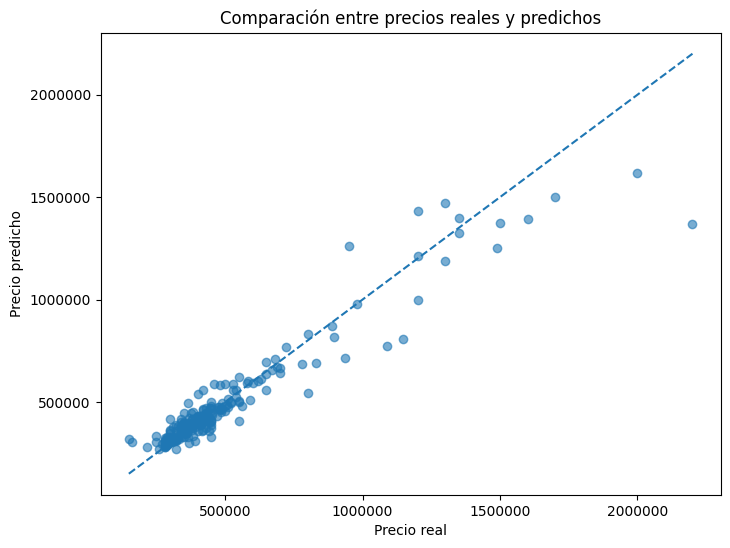

In [31]:
# ============================================================
# 27. Gráfico de valores reales vs predichos
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Comparación entre precios reales y predichos")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

## Análisis de residuos

El análisis de residuos permite observar la diferencia entre los valores reales y los valores predichos por el modelo.

Idealmente, los residuos deberían distribuirse de forma relativamente equilibrada alrededor de cero. Patrones marcados o errores muy altos pueden indicar que el modelo tiene mayor dificultad para estimar ciertos tipos de propiedades, especialmente aquellas con valores atípicos o precios más elevados.

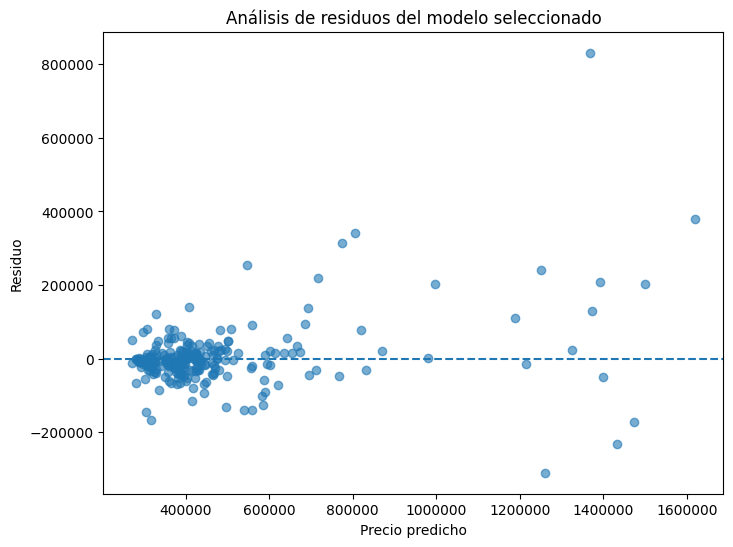

In [32]:
# ============================================================
# 28. Análisis de residuos
# ============================================================

residuos = y_test - y_pred_best

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_best, residuos, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Precio predicho")
plt.ylabel("Residuo")
plt.title("Análisis de residuos del modelo seleccionado")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

## Distribución de errores absolutos

Además del error promedio, se analizó la distribución de errores absolutos para comprender mejor la magnitud de las diferencias entre precios reales y predichos.

Esto permite identificar si el modelo suele cometer errores moderados o si existen casos puntuales con errores significativamente más altos.

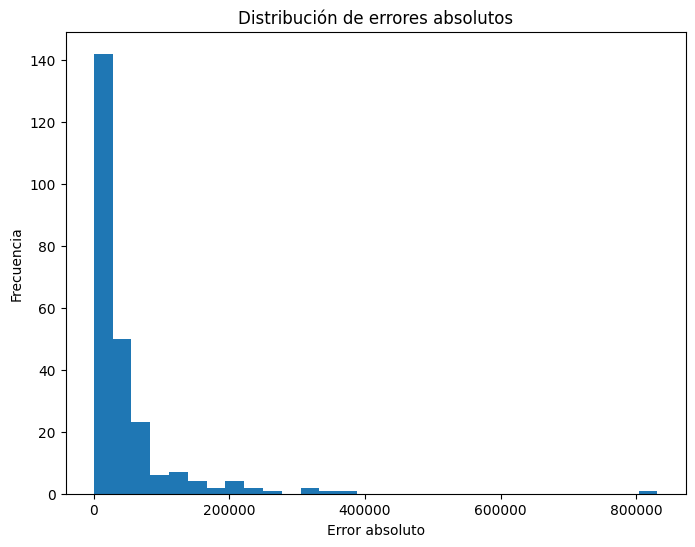

Error absoluto promedio: 45712.0
Error absoluto mediano: 20349.0


In [33]:
# ============================================================
# 29. Distribución de errores absolutos
# ============================================================

errores_absolutos = np.abs(y_test - y_pred_best)

plt.figure(figsize=(8, 6))
plt.hist(errores_absolutos, bins=30)

plt.xlabel("Error absoluto")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores absolutos")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

print("Error absoluto promedio:", round(errores_absolutos.mean(), 0))
print("Error absoluto mediano:", round(np.median(errores_absolutos), 0))

## Importancia de variables

Para interpretar el comportamiento del modelo seleccionado, se calculó la importancia de variables mediante permutación.

Este método evalúa cuánto se deteriora el desempeño del modelo cuando se altera aleatoriamente una variable. Mientras mayor sea el impacto, mayor es la importancia de dicha variable en la predicción del precio de arriendo.

In [34]:
# ============================================================
# 30. Importancia de variables por permutación
# ============================================================

perm_importance = permutation_importance(
    mejor_modelo,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(by="Importancia", ascending=False)

importance_df.head(15)

,Variable,Importancia
24,zona_comuna,19186.356337
0,superficie_total,17012.908453
1,superficie_util,16156.797222
5,banos,15829.911852
17,comuna,10610.032246
9,gastos_comunes,8236.874758
4,dormitorios,7508.834110
16,longitude,5493.571280
6,estacionamientos,3648.015870
18,tiene_estacionamiento,2725.018600


## Visualización de variables más relevantes

Se graficaron las variables con mayor importancia para facilitar la interpretación del modelo.

Esta visualización permite identificar qué atributos tienen mayor influencia en la estimación del precio de arriendo, como ubicación, superficie, gastos comunes y características físicas de la propiedad.

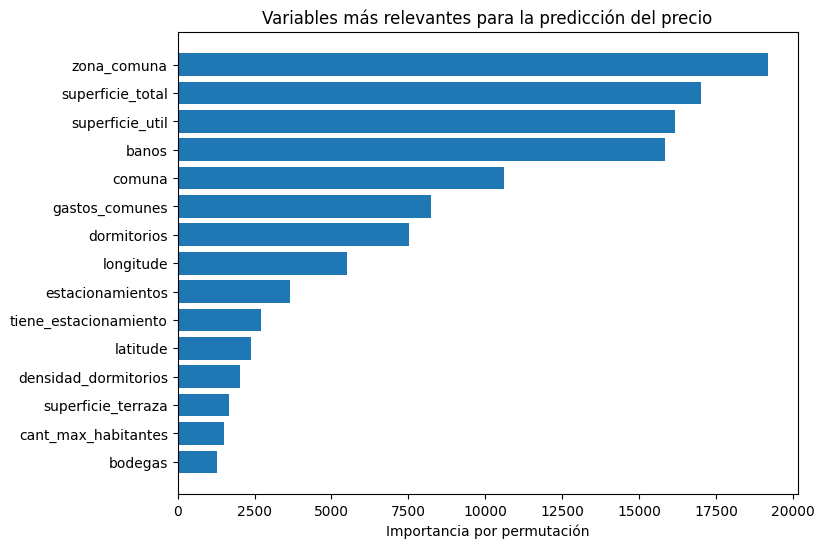

In [35]:
# ============================================================
# 31. Gráfico de importancia de variables
# ============================================================

top_importance = importance_df.head(15).sort_values(by="Importancia")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["Variable"], top_importance["Importancia"])

plt.xlabel("Importancia por permutación")
plt.title("Variables más relevantes para la predicción del precio")
plt.show()

## Exportación del modelo final

Finalmente, el modelo seleccionado fue guardado en formato `.pkl` mediante `joblib`.

Esto permite reutilizar el modelo posteriormente sin necesidad de volver a entrenarlo, facilitando su uso en futuras etapas del proyecto, como una aplicación web, dashboard o sistema de predicción.

In [36]:
# ============================================================
# 32. Guardar modelo final
# ============================================================

joblib.dump(mejor_modelo, "modelo_prediccion_arriendos_rm.pkl")

print("Modelo guardado como: modelo_prediccion_arriendos_rm.pkl")

Modelo guardado como: modelo_prediccion_arriendos_rm.pkl


## Conclusiones finales

El proyecto permitió evolucionar desde un análisis exploratorio del mercado de arriendos hacia la construcción de modelos predictivos de Machine Learning. A partir del dataset trabajado, se modeló el precio mensual de arriendo como un problema de regresión supervisada.

Durante el desarrollo se aplicaron técnicas de limpieza de datos, tratamiento de valores anómalos, ingeniería de atributos, normalización, codificación de variables categóricas, entrenamiento de modelos, validación cruzada, optimización de hiperparámetros y modelamiento ensemble.

Los resultados muestran que el modelo seleccionado permite estimar precios de arriendo con un nivel de precisión razonable para apoyar análisis de mercado. Desde una perspectiva de negocio, este modelo puede ser útil para inversionistas, arrendatarios y analistas inmobiliarios que busquen comparar propiedades similares o identificar inmuebles potencialmente sobrevalorados o subvalorados.

No obstante, el modelo debe interpretarse como una herramienta de apoyo y no como una tasación inmobiliaria definitiva. Futuras mejoras podrían incorporar variables externas como cercanía a estaciones de metro, seguridad del sector, antigüedad del edificio, conectividad, equipamiento urbano y demanda inmobiliaria por comuna.